# 08_results_comparison

The objective of this notebook is to compare the optimized roster to the true results of the 2025-2026 season Stanley Cup Playoffs. 

My optimized roster placed 13th out of 38 teams.

This notebook will be pretty exploratory/ad-hoc so it might be a bit unorganized.

In [361]:
import pandas as pd

# Write out the roster/results into a df

df = pd.DataFrame({
    "Position": [
        "F","F","F","F","F","F","F","F","F",
        "D","D","D","D","D","D",
        "G","G"
    ],
    "Player": [
        "Nathan MacKinnon",
        "Martin Necas",
        "Connor McDavid",
        "Leon Draisaitl",
        "Nikita Kucherov",
        "Jason Robertson",
        "Tage Thompson",
        "Cole Caufield",
        "Wyatt Johnston",
        "Cale Makar",
        "Evan Bouchard",
        "Rasmus Dahlin",
        "Shayne Gostisbehere",
        "Darren Raddysh",
        "Lane Hutson",
        "Scott Wedgewood",
        "Brandon Bussi"
    ],
    "Team": [
        "COL","COL","EDM","EDM","TBL","DAL","BUF","MTL","DAL",
        "COL","EDM","BUF","CAR","TBL","MTL",
        "COL","CAR"
    ],
    "ExpectedGames": [
        15.35,15.35,11.43,11.43,10.08,11.80,13.34,11.11,11.80,
        15.35,11.43,13.34,13.22,10.08,11.11,
        15.35,13.22
    ],
    "ActualGames": [
        13,13,6,6,7,6,13,19,6,
        13,6,13,19,7,19,
        13,19
    ],
    "ExpectedPoints": [
        34.54,27.16,25.93,23.21,23.09,20.30,19.92,19.08,18.86,
        20.26,16.17,16.11,15.14,12.71,12.20,
        13.65,12.20
    ],
    "ActualPoints": [
        22,14,7,13,7,13,20,19,10,
        9,8,18,15,3,19,
        7,5
    ]
})

df["PredictionError"] = df["ActualPoints"] - df["ExpectedPoints"]


In [362]:
df.head()

,Position,Player,Team,ExpectedGames,ActualGames,ExpectedPoints,ActualPoints,PredictionError
0,F,Nathan MacKinnon,COL,15.35,13,34.54,22,-12.54
1,F,Martin Necas,COL,15.35,13,27.16,14,-13.16
2,F,Connor McDavid,EDM,11.43,6,25.93,7,-18.93
3,F,Leon Draisaitl,EDM,11.43,6,23.21,13,-10.21
4,F,Nikita Kucherov,TBL,10.08,7,23.09,7,-16.09


In [363]:
df["ExpectedPoints"].sum()

np.float64(330.53000000000003)

In [364]:
df["ActualPoints"].sum()

np.int64(209)

In [365]:
df["ActualGames"].mean()

np.float64(11.647058823529411)

In [366]:
df["ExpectedGames"].mean()

np.float64(12.634705882352941)

# Grouped Bar Chart

In [367]:
games = df[["Team", "ExpectedGames", "ActualGames"]].drop_duplicates()
games["GamesDiff"] = games["ActualGames"] - games["ExpectedGames"]

games = games.sort_values(by="ExpectedGames", ascending=True)
games

,Team,ExpectedGames,ActualGames,GamesDiff
4,TBL,10.08,7,-3.08
7,MTL,11.11,19,7.89
2,EDM,11.43,6,-5.43
5,DAL,11.80,6,-5.80
12,CAR,13.22,19,5.78
6,BUF,13.34,13,-0.34
0,COL,15.35,13,-2.35


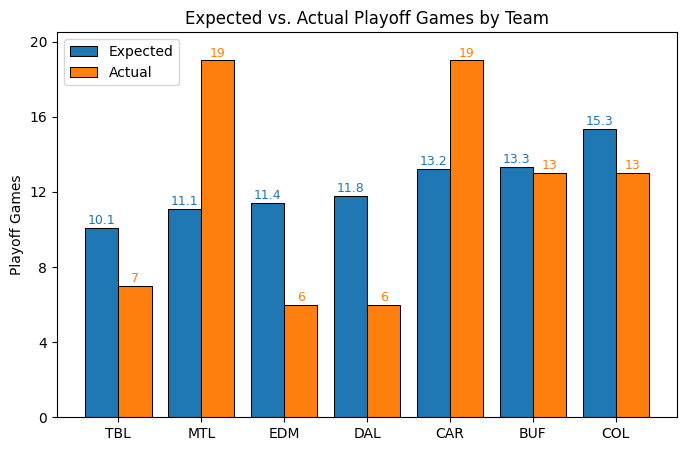

In [368]:
import numpy as np
import matplotlib.pyplot as plt

colors = plt.get_cmap("tab10").colors

x = np.arange(len(games))
width = 0.4

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, games["ExpectedGames"], width, color=colors[0], label="Expected", edgecolor='k', linewidth=0.75)
bars2 = ax.bar(x + width/2, games["ActualGames"], width, color=colors[1], label="Actual", edgecolor='k', linewidth=0.75)

p = 0.5
fs = 9
ax.bar_label(bars1, fmt="%.1f", padding=p, color=colors[0], fontsize=fs)
ax.bar_label(bars2, fmt="%d", padding=p, color=colors[1], fontsize=fs)

ax.set_xticks(x)
ax.set_xticklabels(games["Team"])

ax.set_ylim(0, 20.5)
ax.set_yticks(np.arange(0, 21, 4))

# ax.set_xlabel("Team")
ax.set_ylabel("Playoff Games")
ax.legend(loc='upper left')

ax.set_title("Expected vs. Actual Playoff Games by Team")

plt.show()

# fig.savefig(
#     "../outputs/figures/expected_vs_actual_playoff_games.svg",
#     bbox_inches="tight"
# )

# Do the same thing, but for all the teams

In [369]:
exp_games_played = [(15.351145, 'COL'), (13.337275, 'BUF'), (13.22037, 'CAR'), (11.80482, 'DAL'), (11.429745, 'EDM'), (11.11616, 'MTL'), (11.06145, 'UTA'), (10.313495, 'PHI'), (10.301155, 'VGK'), (10.083305, 'TBL'), (9.82666, 'OTT'), (9.52918, 'MIN'), (9.106675, 'PIT'), (8.7488, 'ANA'), (8.232215, 'BOS'), (6.29599, 'LAK')]
df_exp = pd.DataFrame(exp_games_played, columns=["ExpectedGames", "Team"])

act_games_played = [(13, 'COL'), (13, 'BUF'), (19, 'CAR'), (6, 'DAL'), (6, 'EDM'), (19, 'MTL'), (6, 'UTA'), (10, 'PHI'), (22, 'VGK'), (7, 'TBL'), (4, 'OTT'), (11, 'MIN'), (6, 'PIT'), (12, 'ANA'), (6, 'BOS'), (4, 'LAK')]
df_act = pd.DataFrame(act_games_played, columns=["ActualGames", "Team"])

games = pd.merge(df_exp, df_act, on="Team")


games["PredictionError"] = games["ActualGames"] - games["ExpectedGames"]

games = games.sort_values(by="ExpectedGames")
games.head()


,ExpectedGames,Team,ActualGames,PredictionError
15,6.295990,LAK,4,-2.295990
14,8.232215,BOS,6,-2.232215
13,8.748800,ANA,12,3.251200
12,9.106675,PIT,6,-3.106675
11,9.529180,MIN,11,1.470820


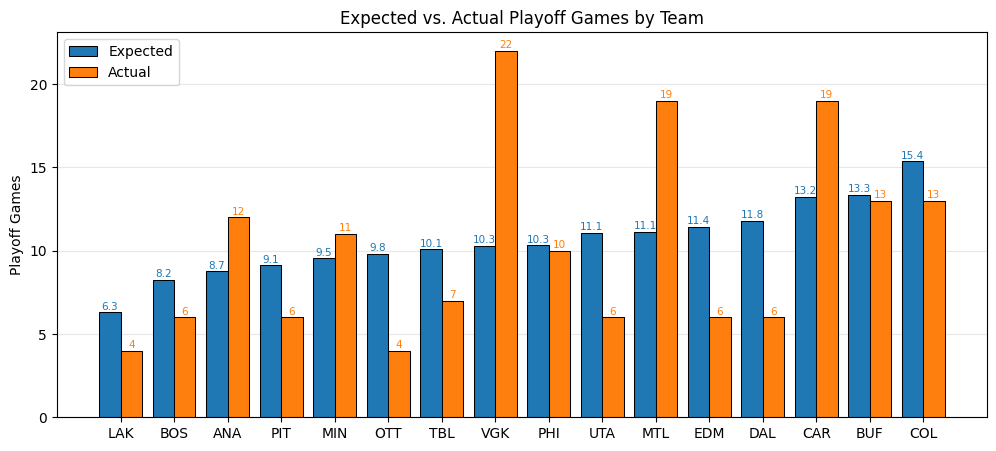

In [370]:
colors = plt.get_cmap("tab10").colors

x = np.arange(len(games))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, games["ExpectedGames"], width, color=colors[0], label="Expected", edgecolor='k', linewidth=0.75)
bars2 = ax.bar(x + width/2, games["ActualGames"], width, color=colors[1], label="Actual", edgecolor='k', linewidth=0.75)

p = 0.5
fs = 7.5
ax.bar_label(bars1, fmt="%.1f", padding=p, color=colors[0], fontsize=fs)
ax.bar_label(bars2, fmt="%d", padding=p, color=colors[1], fontsize=fs)

ax.set_xticks(x)
ax.set_xticklabels(games["Team"])

# ax.set_ylim(0, 20.5)
# ax.set_yticks(np.arange(0, 21, 4))

# ax.set_xlabel("Team")
ax.set_ylabel("Playoff Games")
ax.legend(loc='upper left')

ax.set_title("Expected vs. Actual Playoff Games by Team")

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
# ax.set_ylim(0, 16.5)




plt.show()

# fig.savefig(
#     "../outputs/figures/expected_vs_actual_playoff_games.svg",
#     bbox_inches="tight"
# )

# Dumbbell plot

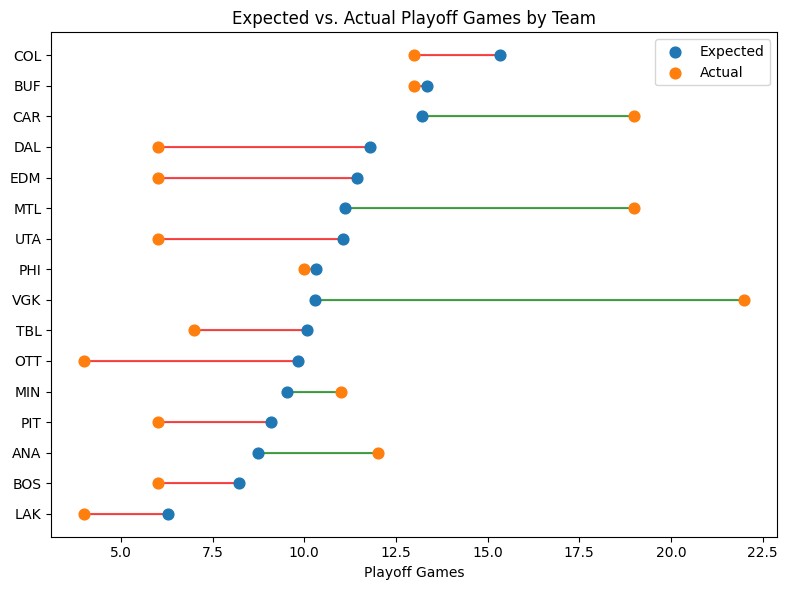

In [371]:

games = games.sort_values("ExpectedGames", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))

y = np.arange(len(games))



# Connecting line
ax.hlines(
    y=y,
    xmin=games["ExpectedGames"],
    xmax=games["ActualGames"],
    color="lightgray",
    linewidth=1,
    zorder=1
)

for i, row in enumerate(games.itertuples()):
    color = "green" if row.ActualGames > row.ExpectedGames else "red"

    ax.hlines(
        y=i,
        xmin=row.ExpectedGames,
        xmax=row.ActualGames,
        color=color,
        linewidth=1.5,
        alpha=0.7,
    )

s = 60
# Expected point
ax.scatter(
    games["ExpectedGames"],
    y,
    s=s,
    label="Expected",
    zorder=2
)

# Actual point
ax.scatter(
    games["ActualGames"],
    y,
    s=s,
    label="Actual",
    zorder=3
)

ax.set_yticks(y)
ax.set_yticklabels(games["Team"])

ax.set_xlabel("Playoff Games")
ax.set_title("Expected vs. Actual Playoff Games by Team")

ax.legend()

plt.tight_layout()
plt.show()

# Games played Error by Team

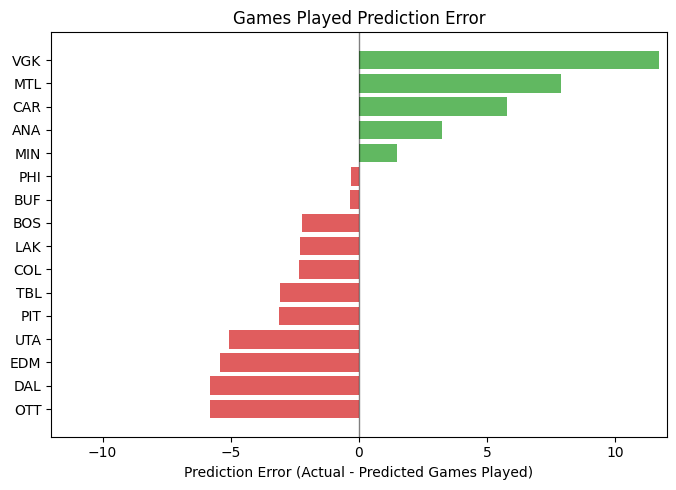

In [372]:

games = games.sort_values(by="PredictionError")

# games = games.sort_values(by="ExpectedGames")
colors = ["tab:green" if x > 0 else "tab:red" for x in games["PredictionError"]]


fig, ax = plt.subplots(figsize=(7,5))

ax.barh(games["Team"], games["PredictionError"], color=colors, alpha=0.75)

# Reference line
ax.axvline(0, color="k", linewidth=1, alpha=0.5)


ax.set_xlabel("Prediction Error (Actual - Predicted Games Played)")
ax.set_title("Games Played Prediction Error")

plt.tight_layout()
ax.set_xlim(-12, 12)
plt.show()

# fig.savefig(
#     "../outputs/figures/games_played_prediction_error.svg",
#     bbox_inches="tight"
# )


# Can I combine the two types of plots?

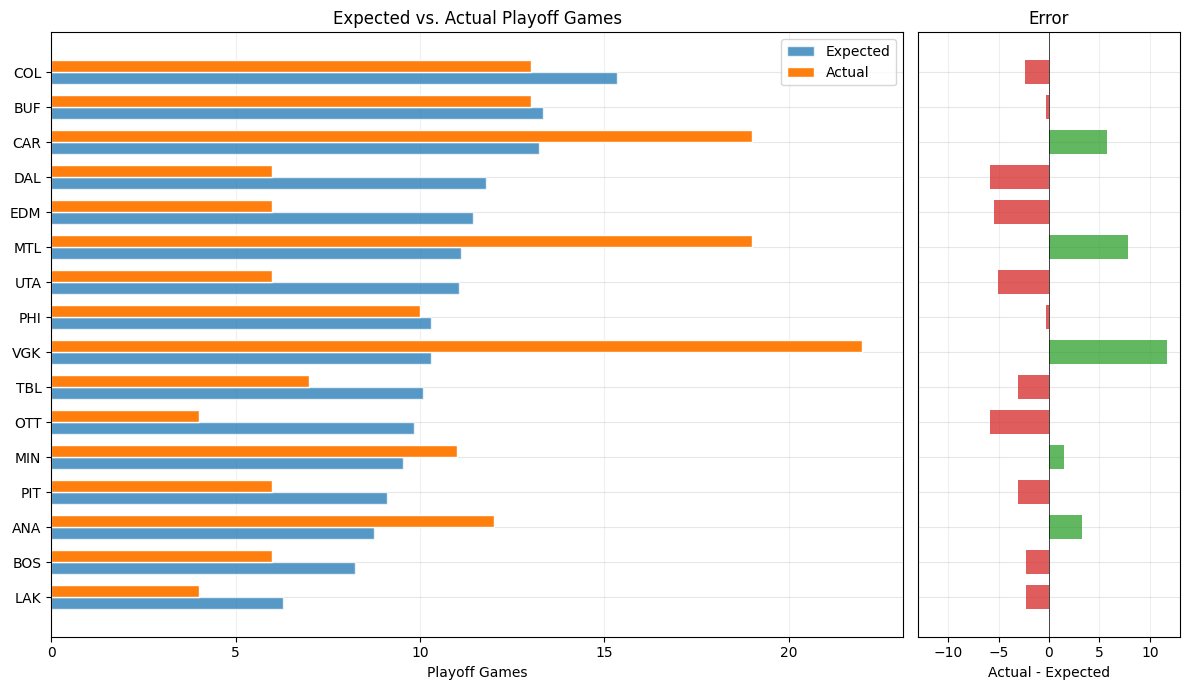

In [373]:
# Sort by expected games (highest first)
games = games.sort_values("ExpectedGames", ascending=False).reset_index(drop=True)

y = np.arange(len(games))
bar_height = 0.35

fig, (ax1, ax2) = plt.subplots(
    nrows=1, ncols=2,
    figsize=(12, 7),
    sharey=True,
    gridspec_kw={"width_ratios": [3.25, 1]}
)

# -------------------------
# Left panel: Grouped bars
# -------------------------
ax1.barh(
    y + bar_height/2,
    games["ExpectedGames"],
    height=bar_height,
    label="Expected",
    edgecolor = "white",
    alpha=0.75
)

ax1.barh(
    y - bar_height/2,
    games["ActualGames"],
    height=bar_height,
    label="Actual",
    edgecolor = "white"
)

ax1.set_yticks(y)
ax1.set_yticklabels(games["Team"])

ax1.set_xlabel("Playoff Games")
# ax1.set_title("Expected vs. Actual")
ax1.legend()

ax1.grid(axis="y", alpha=0.3)
ax1.set_axisbelow(True)


# Value labels
# fs = 7
# for i, row in games.iterrows():
#     ax1.text(row["ExpectedGames"] + 0.15,
#              i + bar_height/2,
#              f"{row['ExpectedGames']:.1f}",
#              va="center",
#              fontsize=fs)

#     ax1.text(row["ActualGames"] + 0.15,
#              i - bar_height/2,
#              f"{row['ActualGames']:.0f}",
#              va="center",
#              fontsize=fs)

# Right panel: Error bars
colors = [
    "tab:green" if e > 0 else "tab:red"
    for e in games["PredictionError"]
]

ax2.barh(
    y,
    games["PredictionError"],
    color=colors,
    alpha=0.75,
    height=bar_height*2
)

ax2.axvline(0, color="black", linewidth=0.5)
ax2.set_xlim([-13, 13])


ax2.set_xlabel("Actual - Expected")
# ax2.set_title("Prediction Error")

## Value labels
# for i, err in enumerate(games["PredictionError"]):
#     if err >= 0:
#         ax2.text(err + 0.15, i, f"{err:.1f}",
#                  va="center", fontsize=fs)
#     else:
#         ax2.text(err - 0.15, i, f"{err:.1f}",
#                  va="center", ha="right", fontsize=fs)

ax2.grid(axis="y", alpha=0.3)

ax2.set_axisbelow(True)

# Put best expected team at top
ax1.invert_yaxis()

ax1.grid(axis="x", alpha=0.2)

ax2.grid(axis="x", alpha=0.2)

# fig.suptitle('Expected vs. Actual Games Played by Team')
# fig.suptitle('Expected vs. Actual Playoff Games (Left) and Prediction Error (Right)')
ax1.set_title("Expected vs. Actual Playoff Games")
ax2.set_title("Error")

ax2.tick_params(axis="y", left=False, labelleft=False)

fig.subplots_adjust(wspace=0.02)

plt.tight_layout()

plt.show()


fig.savefig(
    "../outputs/figures/expected_vs_actual_playoff_games_two_panel.svg",
    bbox_inches="tight"
)

# Prediction Error by Player


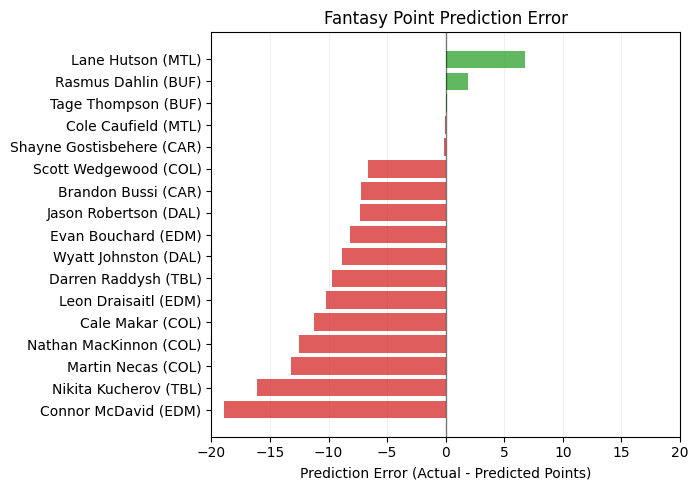

In [374]:
df["Player_Team"] = df["Player"] + " (" + df["Team"] + ")"

df = df.sort_values(by="PredictionError")
colors = ["tab:green" if x > 0 else "tab:red" for x in df["PredictionError"]]


fig, ax = plt.subplots(figsize=(7,5))


ax.grid(axis="x", alpha=0.2)
# ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

ax.barh(df["Player_Team"], df["PredictionError"], color=colors, alpha=0.75)

# Reference line
ax.axvline(0, color="k", linewidth=1, alpha=0.5)


ax.set_xlabel("Prediction Error (Actual - Predicted Points)")
ax.set_title("Fantasy Point Prediction Error")

plt.tight_layout()
ax.set_xlim(-20, 20)

plt.show()





fig.savefig(
    "../outputs/figures/fantasy_prediction_error.svg",
    bbox_inches="tight"
)


# Expected vs Actual Fantasy Points

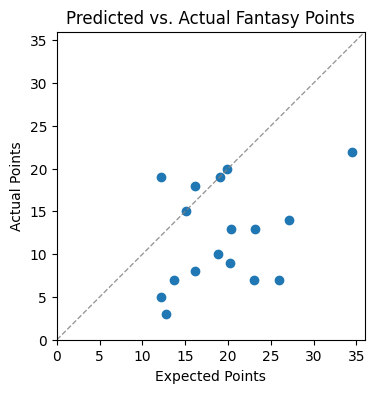

In [375]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(df["ExpectedPoints"], df["ActualPoints"])

# Equal limits
# lims = [min(df["ExpectedPoints"].min(), df["ActualPoints"].min()) * 0.5, 
#         max(df["ExpectedPoints"].max(), df["ActualPoints"].max()) * 1.05]

# lims = [0, 
#         max(df["ExpectedPoints"].max(), df["ActualPoints"].max()) * 1.05]

lims = [0,36]

ticks = range(0, 37, 5)



# reference line
ax.plot(lims, lims, '--', color='gray', linewidth=1, alpha=0.8)


ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xticks(ticks)
ax.set_yticks(ticks)


ax.set_xlabel("Expected Points")
ax.set_ylabel("Actual Points")

ax.set_title("Predicted vs. Actual Fantasy Points")

ax.set_aspect('equal', adjustable='box')

plt.show()

# fig.savefig(
#     "../outputs/figures/expected_vs_actual_fantasy_points.svg",
#     bbox_inches="tight"
# )

# Plots for Monte Carlo Bracket Simulations

In [376]:
import pandas as pd


cup_win_probs = {'COL': 0.194625, 'LAK': 0.00252, 'DAL': 0.088315, 'MIN': 0.03824, 'VGK': 0.022415, 'UTA': 0.031965, 'EDM': 0.025535, 'ANA': 0.006385, 'PHI': 0.03337, 'PIT': 0.01745, 'OTT': 0.061695, 'CAR': 0.166485, 'MTL': 0.08128, 'TBL': 0.055395, 'BOS': 0.02265, 'BUF': 0.151675}
df_cup = (pd.DataFrame(cup_win_probs.items(), columns=["Team", "CupWinProbability"]))

exp_games_played = [(15.351145, 'COL'), (13.337275, 'BUF'), (13.22037, 'CAR'), (11.80482, 'DAL'), (11.429745, 'EDM'), (11.11616, 'MTL'), (11.06145, 'UTA'), (10.313495, 'PHI'), (10.301155, 'VGK'), (10.083305, 'TBL'), (9.82666, 'OTT'), (9.52918, 'MIN'), (9.106675, 'PIT'), (8.7488, 'ANA'), (8.232215, 'BOS'), (6.29599, 'LAK')]

df_games = (pd.DataFrame(exp_games_played, columns=["ExpectedGames", "Team"]))

df = pd.merge(df_games, df_cup, on="Team")

df.head()

,ExpectedGames,Team,CupWinProbability
0,15.351145,COL,0.194625
1,13.337275,BUF,0.151675
2,13.220370,CAR,0.166485
3,11.804820,DAL,0.088315
4,11.429745,EDM,0.025535


In [377]:
team_colors = {
    "COL": "#6F263D",
    "BUF": "#003087",
    "CAR": "#CE1126",
    "DAL": "#006847",
    "EDM": "#041E42",
    "MTL": "#AF1E2D",
    "UTA": "#69B3E7",  
    "PHI": "#F74902",
    "VGK": "#B4975A",
    "TBL": "#002868",
    "OTT": "#DA1A32",
    "MIN": "#154734",
    "PIT": "#FCB514",
    "ANA": "#F47A38",
    "BOS": "#FFB81C",
    "LAK": "#111111",
}

df["TeamColor"] = df["Team"].map(team_colors)
df.head()

,ExpectedGames,Team,CupWinProbability,TeamColor
0,15.351145,COL,0.194625,#6F263D
1,13.337275,BUF,0.151675,#003087
2,13.220370,CAR,0.166485,#CE1126
3,11.804820,DAL,0.088315,#006847
4,11.429745,EDM,0.025535,#041E42


## Expected games

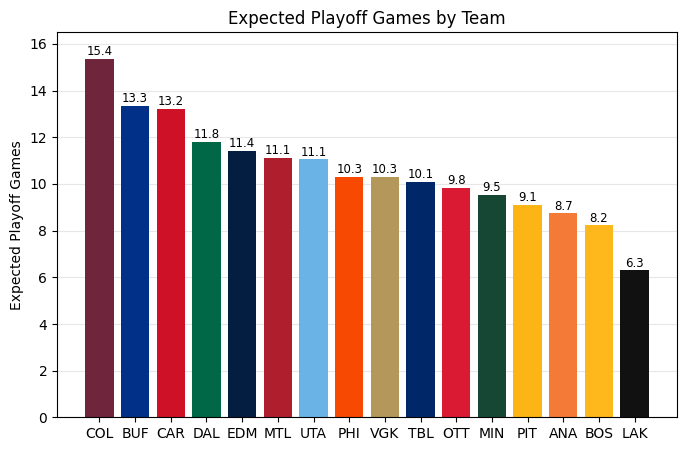

In [378]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,5))

df = df.sort_values(by="ExpectedGames", ascending=False)


colors = [c for c in df["TeamColor"]]


bars = ax.bar(df["Team"], df["ExpectedGames"], color=colors)


p = 0.5
fs = 8.5
ax.bar_label(bars, fmt="%.1f", padding=p, fontsize=fs)

ax.set_ylabel("Expected Playoff Games")
ax.set_title("Expected Playoff Games by Team")

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, 16.5)


plt.show()

# fig.savefig(
#     "../outputs/figures/expected_playoff_games.svg",
#     bbox_inches="tight"
# )


## Stanley Cup Win Probability

In [379]:
df.head()

,ExpectedGames,Team,CupWinProbability,TeamColor
0,15.351145,COL,0.194625,#6F263D
1,13.337275,BUF,0.151675,#003087
2,13.220370,CAR,0.166485,#CE1126
3,11.804820,DAL,0.088315,#006847
4,11.429745,EDM,0.025535,#041E42


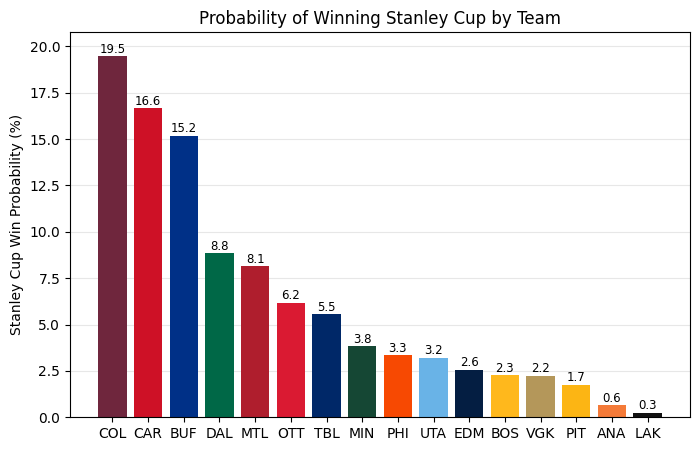

In [380]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,5))

df = df.sort_values(by="CupWinProbability", ascending=False)

colors = [c for c in df["TeamColor"]]


bars = ax.bar(df["Team"], df["CupWinProbability"]*100, color=colors)


p = 0.5
fs = 8.5
ax.bar_label(bars, fmt="%.1f", padding=p, fontsize=fs)

ax.set_ylabel("Stanley Cup Win Probability (%)")
ax.set_title("Probability of Winning Stanley Cup by Team")

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, 20.75)


plt.show()

# fig.savefig(
#     "../outputs/figures/probability_of_winning_stanley_cup.svg",
#     bbox_inches="tight"
# )
